### Task 1: Data Loading and Initial Exploration

In [51]:
# a) Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [52]:
# b) Load the dataset and convert to a DataFrame
breast_cancer_data = load_breast_cancer()

df_cancer_features = pd.DataFrame(breast_cancer_data.data, columns=breast_cancer_data.feature_names)
df_cancer_target = pd.DataFrame(breast_cancer_data.target, columns=['target_label'])

df_combined_cancer = pd.concat([df_cancer_features, df_cancer_target], axis=1)

print("Dataset loaded and converted to DataFrame.")

Dataset loaded and converted to DataFrame.


In [53]:
# c) Display feature names, sample rows, and target class distribution
print("\nFeature Names:")
for feature in breast_cancer_data.feature_names:
    print(f"- {feature}")

print("\nSample Rows (first 5):")
display(df_combined_cancer.head())

print("\nTarget Class Distribution (Malignant vs Benign counts):")
target_counts = df_combined_cancer['target_label'].value_counts().rename(index={0: 'Malignant', 1: 'Benign'})
display(target_counts)

print(f"Target class names: {breast_cancer_data.target_names}")


Feature Names:
- mean radius
- mean texture
- mean perimeter
- mean area
- mean smoothness
- mean compactness
- mean concavity
- mean concave points
- mean symmetry
- mean fractal dimension
- radius error
- texture error
- perimeter error
- area error
- smoothness error
- compactness error
- concavity error
- concave points error
- symmetry error
- fractal dimension error
- worst radius
- worst texture
- worst perimeter
- worst area
- worst smoothness
- worst compactness
- worst concavity
- worst concave points
- worst symmetry
- worst fractal dimension

Sample Rows (first 5):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Target Class Distribution (Malignant vs Benign counts):


,count
target_label,
Benign,357
Malignant,212


Target class names: ['malignant' 'benign']



Dataset Shape: (569, 31) (rows, columns)

Class Balance:


,proportion
target_label,
Benign,62.741652
Malignant,37.258348


/tmp/ipykernel_676/825923155.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')


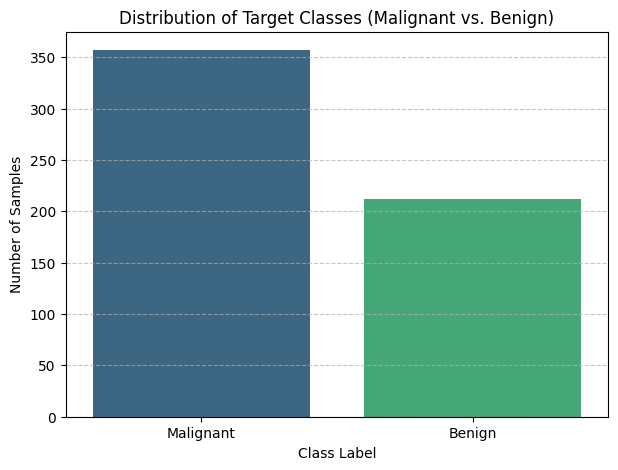

In [54]:
# d) Check dataset shape and class balance; plot a bar chart of class distribution
print(f"\nDataset Shape: {df_combined_cancer.shape} (rows, columns)")

print("\nClass Balance:")
class_balance = df_combined_cancer['target_label'].value_counts(normalize=True).rename(index={0: 'Malignant', 1: 'Benign'}) * 100
display(class_balance)

plt.figure(figsize=(7, 5))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Distribution of Target Classes (Malignant vs. Benign)')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(ticks=[0, 1], labels=['Malignant', 'Benign'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Task 2: Data Pre-processing and Splitting

In [55]:
# a) Check for missing/null values
print("\nChecking for missing values:")
missing_values = df_combined_cancer.isnull().sum()
missing_values = missing_values[missing_values > 0]
if missing_values.empty:
    print("No missing values found in the dataset.")
else:
    display(missing_values.sort_values(ascending=False))
    print(f"Total missing values: {missing_values.sum()}")


Checking for missing values:
No missing values found in the dataset.


In [56]:
# b) Standardize features using StandardScaler
from sklearn.preprocessing import StandardScaler

print("\nStandardizing features...")

X = df_combined_cancer.drop('target_label', axis=1)
y = df_combined_cancer['target_label']

scaler_data_points = StandardScaler()
X_scaled_features = scaler_data_points.fit_transform(X)

df_scaled_features = pd.DataFrame(X_scaled_features, columns=X.columns)

print("Features standardized successfully.")
print("Sample of scaled features (first 5 rows):")
display(df_scaled_features.head())


Standardizing features...
Features standardized successfully.
Sample of scaled features (first 5 rows):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,2.489734,-0.565265,2.833031,2.487578,-0.214002,1.316862,0.724026,0.660820,1.148757,0.907083,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,0.499255,-0.876244,0.263327,0.742402,-0.605351,-0.692926,-0.440780,0.260162,-0.805450,-0.099444,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,1.228676,-0.780083,0.850928,1.181336,-0.297005,0.814974,0.213076,1.424827,0.237036,0.293559,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,0.326373,-0.110409,0.286593,-0.288378,0.689702,2.744280,0.819518,1.115007,4.732680,2.047511,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,1.270543,-0.790244,1.273189,1.190357,1.483067,-0.048520,0.828471,1.144205,-0.361092,0.499328,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [57]:
# c) Split into training and testing sets (80-20 split, stratified on target)
from sklearn.model_selection import train_test_split

print("\nSplitting data into training and testing sets (80-20 split, stratified)...")

X_train_set, X_test_set, y_train_labels, y_test_labels = train_test_split(df_scaled_features, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train_set shape: {X_train_set.shape}")
print(f"X_test_set shape: {X_test_set.shape}")
print(f"y_train_labels shape: {y_train_labels.shape}")
print(f"y_test_labels shape: {y_test_labels.shape}")

print("Data split successfully.")


Splitting data into training and testing sets (80-20 split, stratified)...
X_train_set shape: (455, 30)
X_test_set shape: (114, 30)
y_train_labels shape: (455,)
y_test_labels shape: (114,)
Data split successfully.



Summary Statistics of Scaled Features (first 5 rows and selected columns for brevity):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,-1.373633e-16,6.868164e-17,-1.248757e-16,-2.185325e-16,-8.366672e-16,1.873136e-16,4.995028e-17,-4.995028e-17,1.748260e-16,4.745277e-16,2.372638e-16,-1.123881e-16,-1.123881e-16,-1.311195e-16,-1.529727e-16,1.748260e-16,1.623384e-16,0.000000,8.741299e-17,-6.243785e-18,-8.241796e-16,1.248757e-17,-3.746271e-16,0.000000,-2.372638e-16,-3.371644e-16,7.492542e-17,2.247763e-16,2.622390e-16,-5.744282e-16
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,-1.819865e+00,-1.059924e+00,-1.554264e+00,-1.044049e+00,-7.378291e-01,-1.776065e+00,-1.298098e+00,-1.057501e+00,-1.913447,-1.532890e+00,-1.096968e+00,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423,-2.682695e+00,-1.443878e+00,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,-7.226392e-01,-6.235706e-01,-6.948092e-01,-6.237679e-01,-4.947542e-01,-6.240183e-01,-6.929263e-01,-5.571612e-01,-0.674490,-6.516807e-01,-5.851185e-01,-6.749213e-01,-7.486293e-01,-6.895783e-01,-0.642136,-6.912304e-01,-6.810833e-01,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01



Generating Correlation Heatmap...


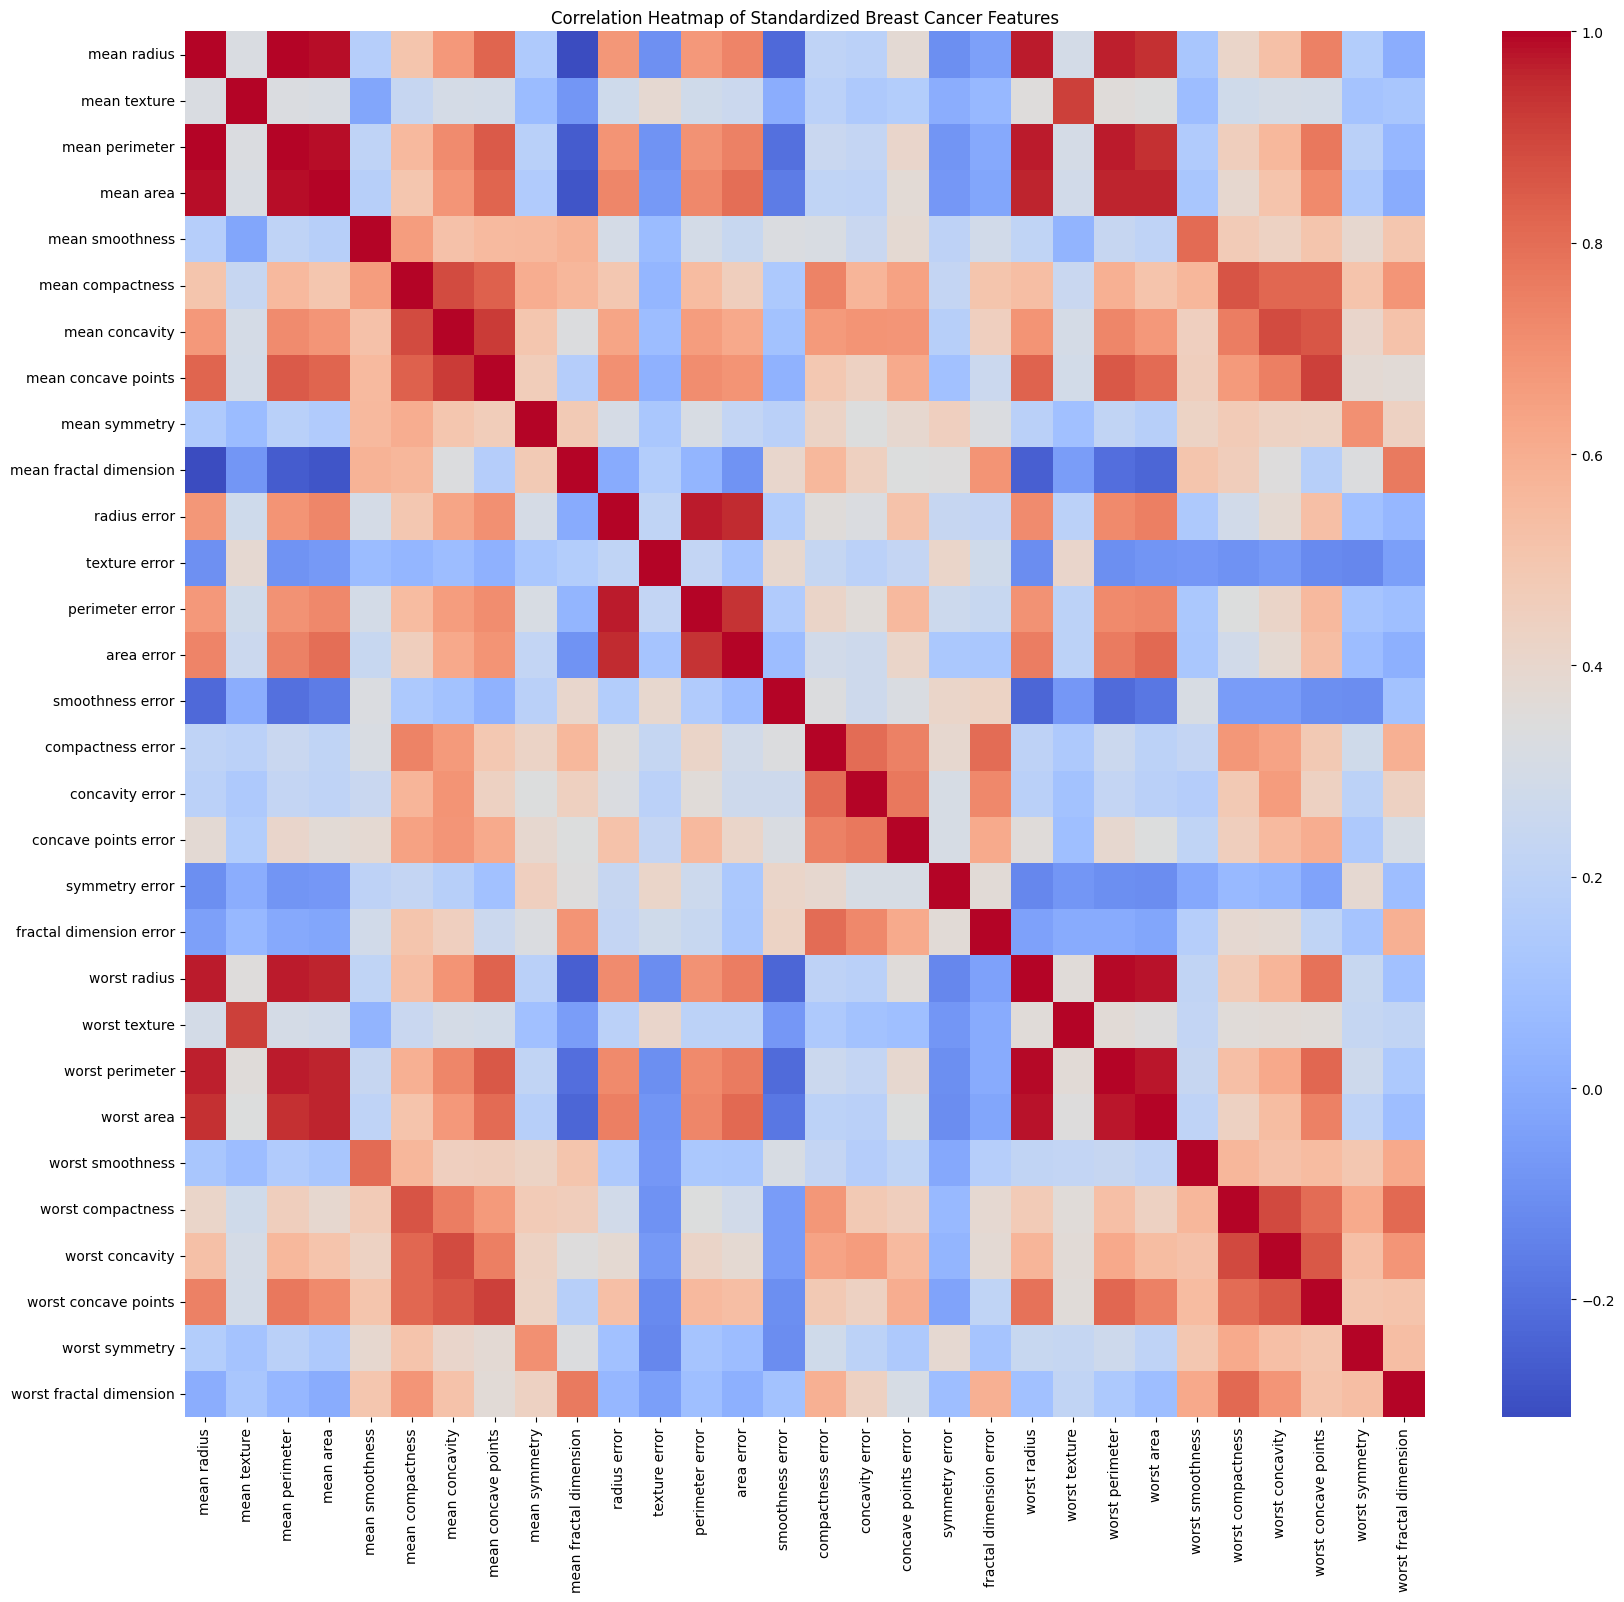

Correlation Heatmap displayed.


In [58]:
# d) Print summary statistics per feature and show a correlation heatmap
print("\nSummary Statistics of Scaled Features (first 5 rows and selected columns for brevity):")
display(df_scaled_features.describe().head())

print("\nGenerating Correlation Heatmap...")
plt.figure(figsize=(20, 18))
sns.heatmap(df_scaled_features.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Standardized Breast Cancer Features')
plt.show()
print("Correlation Heatmap displayed.")

### Task 3: Implementing Support Vector Machine (SVM)

In [59]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

model_performance_metrics = {}

print("\nTraining SVM models...")

print("\nTraining SVM with Linear Kernel...")
svm_linear_classifier = SVC(kernel='linear', random_state=42)
start_time_linear = time.time()
svm_linear_classifier.fit(X_train_set, y_train_labels)
end_time_linear = time.time()
training_time_linear = end_time_linear - start_time_linear

y_pred_linear = svm_linear_classifier.predict(X_test_set)
accuracy_linear = accuracy_score(y_test_labels, y_pred_linear)

print(f"SVM (Linear Kernel) Training Time: {training_time_linear:.4f} seconds")
print(f"SVM (Linear Kernel) Accuracy: {accuracy_linear:.4f}")

model_performance_metrics['SVM_Linear'] = {
    'training_time': training_time_linear,
    'accuracy': accuracy_linear,
    'model': svm_linear_classifier
}

print("\nTraining SVM with RBF Kernel...")
svm_rbf_classifier = SVC(kernel='rbf', random_state=42)
start_time_rbf = time.time()
svm_rbf_classifier.fit(X_train_set, y_train_labels)
end_time_rbf = time.time()
training_time_rbf = end_time_rbf - start_time_rbf

y_pred_rbf = svm_rbf_classifier.predict(X_test_set)
accuracy_rbf = accuracy_score(y_test_labels, y_pred_rbf)

print(f"SVM (RBF Kernel) Training Time: {training_time_rbf:.4f} seconds")
print(f"SVM (RBF Kernel) Accuracy: {accuracy_rbf:.4f}")

model_performance_metrics['SVM_RBF'] = {
    'training_time': training_time_rbf,
    'accuracy': accuracy_rbf,
    'model': svm_rbf_classifier
}

print("\nSVM model training complete.")


Training SVM models...

Training SVM with Linear Kernel...
SVM (Linear Kernel) Training Time: 0.0096 seconds
SVM (Linear Kernel) Accuracy: 0.9737

Training SVM with RBF Kernel...
SVM (RBF Kernel) Training Time: 0.0102 seconds
SVM (RBF Kernel) Accuracy: 0.9825

SVM model training complete.


### Task 4: Implementing Ensemble Classifiers

In [60]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

print("\nTraining Ensemble Classifiers...")

print("\nTraining Bagging Classifier...")
bagging_base_estimator = DecisionTreeClassifier(random_state=42)
bagging_classifier = BaggingClassifier(estimator=bagging_base_estimator, n_estimators=100, random_state=42, n_jobs=-1)
start_time_bagging = time.time()
bagging_classifier.fit(X_train_set, y_train_labels)
end_time_bagging = time.time()
training_time_bagging = end_time_bagging - start_time_bagging

model_performance_metrics['Bagging'] = {
    'training_time': training_time_bagging,
    'model': bagging_classifier
}
print(f"Bagging Classifier Training Time: {training_time_bagging:.4f} seconds")

print("\nTraining Random Forest Classifier...")
random_forest_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
start_time_rf = time.time()
random_forest_classifier.fit(X_train_set, y_train_labels)
end_time_rf = time.time()
training_time_rf = end_time_rf - start_time_rf

model_performance_metrics['Random_Forest'] = {
    'training_time': training_time_rf,
    'model': random_forest_classifier
}
print(f"Random Forest Classifier Training Time: {training_time_rf:.4f} seconds")

print("\nTraining Gradient Boosting Classifier...")
gradient_boosting_classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
start_time_gb = time.time()
gradient_boosting_classifier.fit(X_train_set, y_train_labels)
end_time_gb = time.time()
training_time_gb = end_time_gb - start_time_gb

model_performance_metrics['Gradient_Boosting'] = {
    'training_time': training_time_gb,
    'model': gradient_boosting_classifier
}
print(f"Gradient Boosting Classifier Training Time: {training_time_gb:.4f} seconds")

print("\nTraining XGBoost Classifier (tuned parameters)...")
xgb_classifier = XGBClassifier(
    objective='binary:logistic',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
start_time_xgb = time.time()
xgb_classifier.fit(X_train_set, y_train_labels)
end_time_xgb = time.time()
training_time_xgb = end_time_xgb - start_time_xgb

model_performance_metrics['XGBoost'] = {
    'training_time': training_time_xgb,
    'model': xgb_classifier
}
print(f"XGBoost Classifier Training Time: {training_time_xgb:.4f} seconds")

print("\nAll ensemble model training complete.")


Training Ensemble Classifiers...

Training Bagging Classifier...
Bagging Classifier Training Time: 0.8683 seconds

Training Random Forest Classifier...
Random Forest Classifier Training Time: 0.4874 seconds

Training Gradient Boosting Classifier...
Gradient Boosting Classifier Training Time: 1.3348 seconds

Training XGBoost Classifier (tuned parameters)...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [13:37:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Training Time: 1.0247 seconds

All ensemble model training complete.


In [61]:
### Task 6: Dimensionality Reduction, Visualization, and Discussion

### Task 5: Analyzing Model Performance

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

all_model_results = []

print("\nCalculating performance metrics for all models...")

svm_linear_classifier = model_performance_metrics['SVM_Linear']['model']
y_pred_linear_svm = svm_linear_classifier.predict(X_test_set)
model_performance_metrics['SVM_Linear']['y_pred'] = y_pred_linear_svm
model_performance_metrics['SVM_Linear']['y_proba'] = svm_linear_classifier.decision_function(X_test_set)

svm_rbf_classifier = model_performance_metrics['SVM_RBF']['model']
y_pred_rbf_svm = svm_rbf_classifier.predict(X_test_set)
model_performance_metrics['SVM_RBF']['y_pred'] = y_pred_rbf_svm
model_performance_metrics['SVM_RBF']['y_proba'] = svm_rbf_classifier.decision_function(X_test_set)

for model_name, data in model_performance_metrics.items():
    model = data['model']
    if 'y_pred' not in data:
        y_pred_val = model.predict(X_test_set)
        data['y_pred'] = y_pred_val
    else:
        y_pred_val = data['y_pred']

    if 'y_proba' not in data:
        if hasattr(model, 'predict_proba'):
            y_proba_val = model.predict_proba(X_test_set)[:, 1]
            data['y_proba'] = y_proba_val
        else:
            y_proba_val = model.decision_function(X_test_set)
            data['y_proba'] = y_proba_val
    else:
        y_proba_val = data['y_proba']

    model_accuracy = accuracy_score(y_test_labels, y_pred_val)
    model_precision = precision_score(y_test_labels, y_pred_val)
    model_recall = recall_score(y_test_labels, y_pred_val)
    model_f1 = f1_score(y_test_labels, y_pred_val)
    model_conf_matrix = confusion_matrix(y_test_labels, y_pred_val)

    current_model_results = {
        'model_name': model_name,
        'accuracy': model_accuracy,
        'precision': model_precision,
        'recall': model_recall,
        'f1_score': model_f1,
        'confusion_matrix': model_conf_matrix,
        'training_time': data['training_time']
    }
    all_model_results.append(current_model_results)

    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {model_accuracy:.4f}")
    print(f"Precision: {model_precision:.4f}")
    print(f"Recall: {model_recall:.4f}")
    print(f"F1-Score: {model_f1:.4f}")
    print("Confusion Matrix:")
    display(pd.DataFrame(model_conf_matrix, index=['Actual Malignant', 'Actual Benign'], columns=['Predicted Malignant', 'Predicted Benign']))

print("\nAll model performance metrics calculated.")


Calculating performance metrics for all models...

--- SVM_Linear ---
Accuracy: 0.9737
Precision: 0.9859
Recall: 0.9722
F1-Score: 0.9790
Confusion Matrix:


,Predicted Malignant,Predicted Benign
Actual Malignant,41,1
Actual Benign,2,70



--- SVM_RBF ---
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1-Score: 0.9861
Confusion Matrix:


,Predicted Malignant,Predicted Benign
Actual Malignant,41,1
Actual Benign,1,71



--- Bagging ---
Accuracy: 0.9386
Precision: 0.9452
Recall: 0.9583
F1-Score: 0.9517
Confusion Matrix:


...


--- Gradient_Boosting ---
Accuracy: 0.9561
Precision: 0.9467
Recall: 0.9861
F1-Score: 0.9660
Confusion Matrix:


,Predicted Malignant,Predicted Benign
Actual Malignant,38,4
Actual Benign,1,71



--- XGBoost ---
Accuracy: 0.9474
Precision: 0.9459
Recall: 0.9722
F1-Score: 0.9589
Confusion Matrix:


,Predicted Malignant,Predicted Benign
Actual Malignant,38,4
Actual Benign,2,70



All model performance metrics calculated.



Plotting ROC Curves and calculating AUC scores...


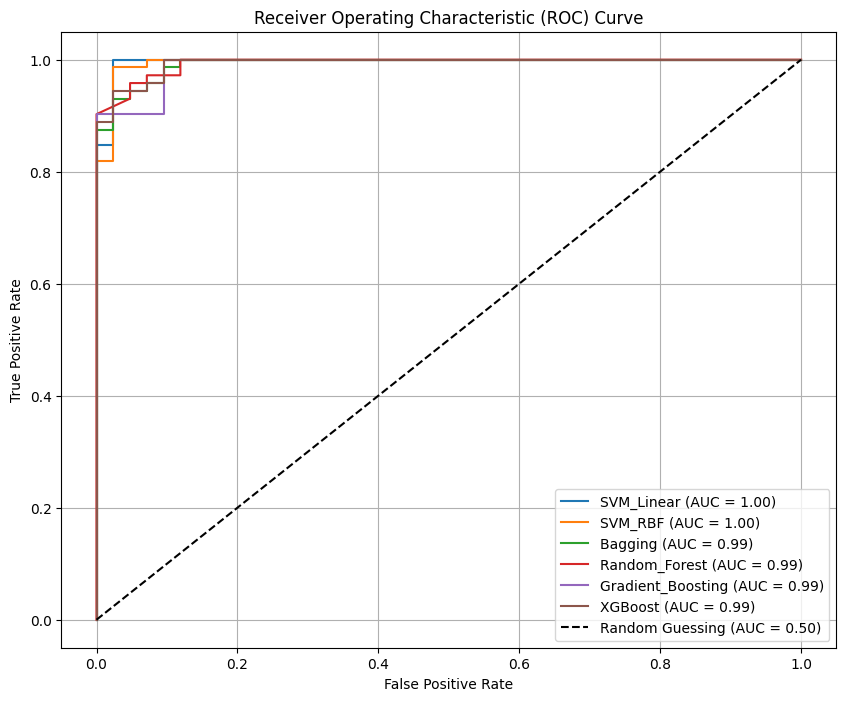

ROC curves plotted and AUC scores compared.


In [63]:
# b) Plot ROC curves and compare AUC scores across all models on one chart.
plt.figure(figsize=(10, 8))

print("\nPlotting ROC Curves and calculating AUC scores...")

for model_name, data in model_performance_metrics.items():
    y_proba = data['y_proba']

    fpr, tpr, _ = roc_curve(y_test_labels, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("ROC curves plotted and AUC scores compared.")

In [64]:
# c) Create a summary comparison table (model vs accuracy vs F1 vs training time).

print("\nCreating summary comparison table...")

df_summary = pd.DataFrame(all_model_results)
df_summary = df_summary[['model_name', 'accuracy', 'f1_score', 'training_time']]
df_summary = df_summary.set_index('model_name')

df_summary = df_summary.sort_values(by='f1_score', ascending=False)

print("Model Performance Summary:")
display(df_summary)

print("Summary comparison table created.")


Creating summary comparison table...
Model Performance Summary:


,accuracy,f1_score,training_time
model_name,,,
SVM_RBF,0.982456,0.986111,0.010194
SVM_Linear,0.973684,0.979021,0.009552
Gradient_Boosting,0.956140,0.965986,1.334798
Random_Forest,0.956140,0.965517,0.487405
XGBoost,0.947368,0.958904,1.024673
Bagging,0.938596,0.951724,0.868294


Summary comparison table created.



Plotting Feature Importance for Tree-based Models...


/tmp/ipykernel_676/1699744655.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_feature_importances.values, y=rf_feature_importances.index, palette='viridis')
/tmp/ipykernel_676/1699744655.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_feature_importances.values, y=xgb_feature_importances.index, palette='magma')


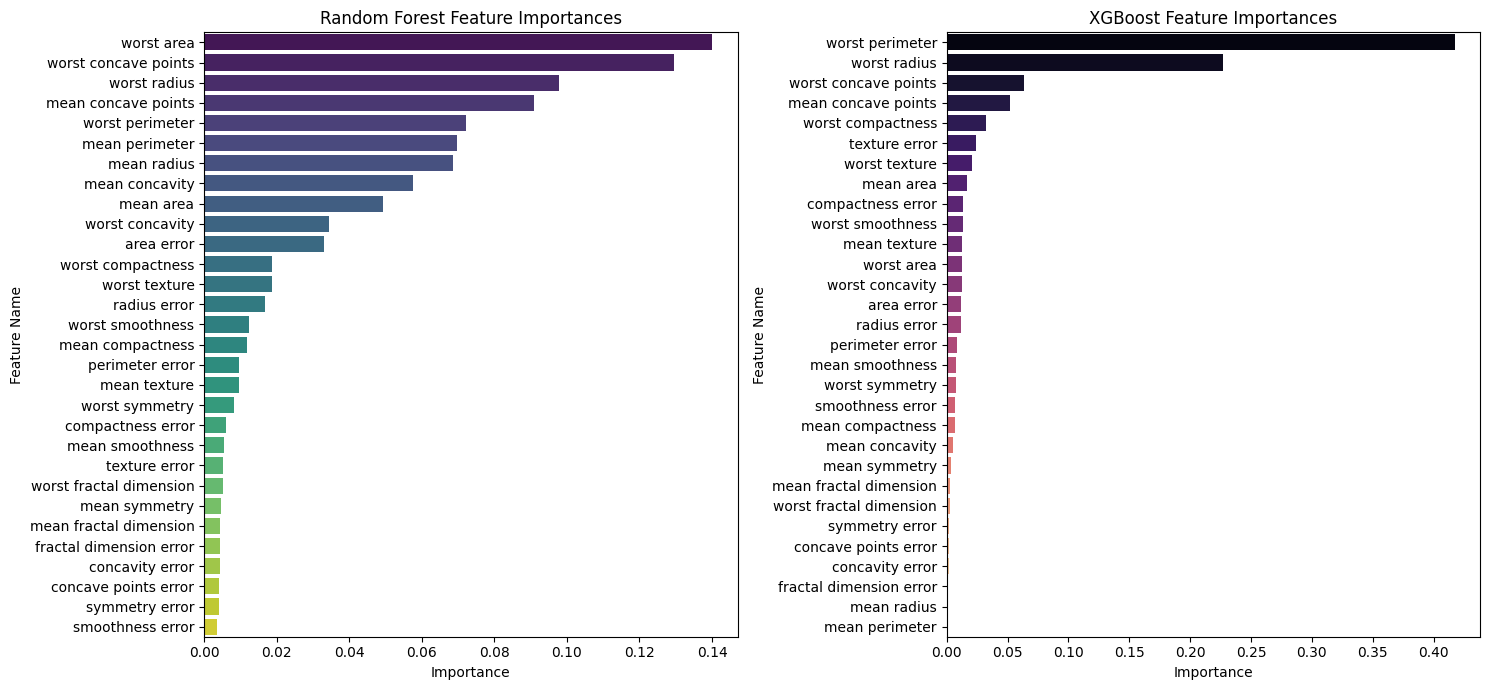

Note: SVM models do not directly provide feature importances in the same way tree-based models do. This can be a point of discussion for model interpretability.
Feature importances plotted for Random Forest and XGBoost.


In [65]:
# d) Plot feature importance from Random Forest/XGBoost (SVM has no direct feature importance — note this as a discussion point).

print("\nPlotting Feature Importance for Tree-based Models...")

plt.figure(figsize=(15, 7))

rf_model = model_performance_metrics['Random_Forest']['model']
rf_feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.subplot(1, 2, 1)
sns.barplot(x=rf_feature_importances.values, y=rf_feature_importances.index, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature Name')

xgb_model = model_performance_metrics['XGBoost']['model']
xgb_feature_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.subplot(1, 2, 2)
sns.barplot(x=xgb_feature_importances.values, y=xgb_feature_importances.index, palette='magma')
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature Name')

plt.tight_layout()
plt.show()

print("Note: SVM models do not directly provide feature importances in the same way tree-based models do. This can be a point of discussion for model interpretability.")
print("Feature importances plotted for Random Forest and XGBoost.")

### Task 6: Dimensionality Reduction, Visualization, and Discussion


Performing PCA for 2 components...
PCA completed. Visualizing decision boundaries...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [13:37:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


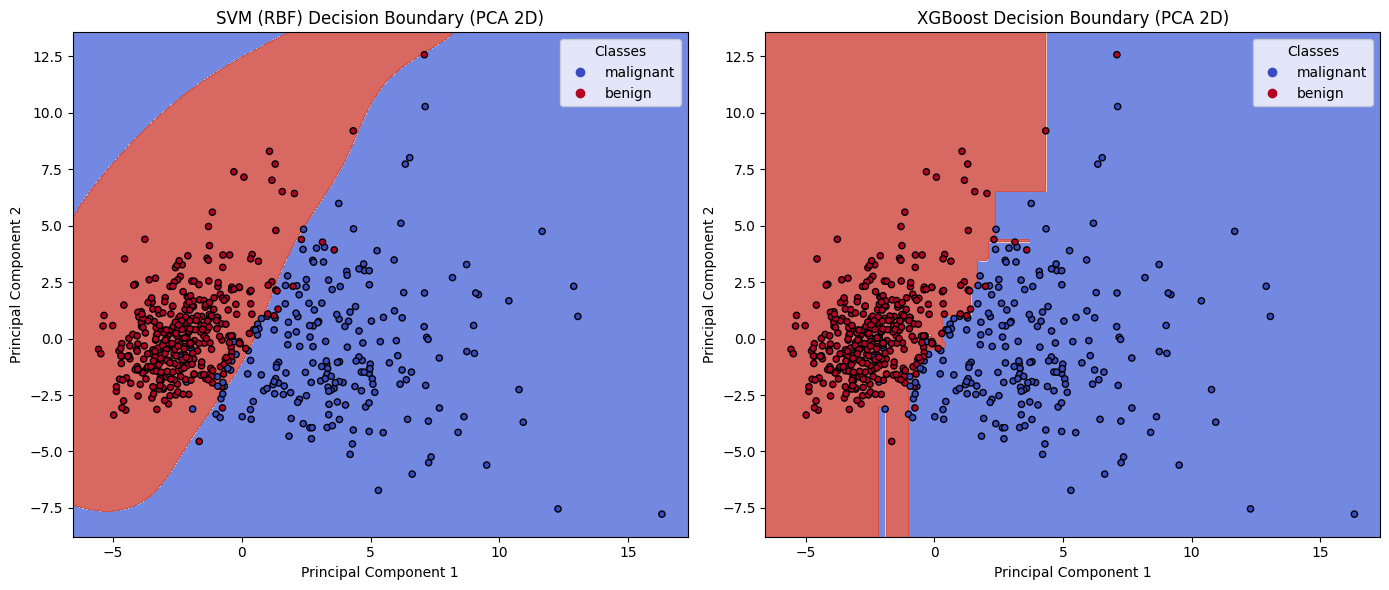

Decision boundaries visualized using PCA.


In [66]:
# a) Reduce dimensions using PCA to 2 components and visualize decision boundaries for SVM vs XGBoost side by side.
from sklearn.decomposition import PCA

print("\nPerforming PCA for 2 components...")

pca_transform = PCA(n_components=2)
X_pca_data = pca_transform.fit_transform(X_scaled_features)

# Create a DataFrame for PCA results for easier plotting
df_pca = pd.DataFrame(data=X_pca_data, columns=['principal_component_1', 'principal_component_2'])
df_pca['target_label'] = y.values

print("PCA completed. Visualizing decision boundaries...")

def plot_decision_boundary(model, X_plot, y_plot, ax, title):
    # Re-train model on PCA data for visualization
    model_for_plot = model.__class__(**model.get_params())
    model_for_plot.fit(X_plot[:, :2], y_plot)

    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model_for_plot.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    scatter = ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_title(title)
    ax.legend(handles=scatter.legend_elements()[0], labels=list(breast_cancer_data.target_names), title="Classes")

plt.figure(figsize=(14, 6))

# Plot SVM (RBF) decision boundary
ax1 = plt.subplot(1, 2, 1)
plot_decision_boundary(model_performance_metrics['SVM_RBF']['model'], X_pca_data, y, ax1, 'SVM (RBF) Decision Boundary (PCA 2D)')

# Plot XGBoost decision boundary
ax2 = plt.subplot(1, 2, 2)
plot_decision_boundary(model_performance_metrics['XGBoost']['model'], X_pca_data, y, ax2, 'XGBoost Decision Boundary (PCA 2D)')

plt.tight_layout()
plt.show()

print("Decision boundaries visualized using PCA.")

#### Model Performance Comparison

Let's re-examine the summary table:


In [67]:
display(df_summary)


,accuracy,f1_score,training_time
model_name,,,
SVM_RBF,0.982456,0.986111,0.010194
SVM_Linear,0.973684,0.979021,0.009552
Gradient_Boosting,0.956140,0.965986,1.334798
Random_Forest,0.956140,0.965517,0.487405
XGBoost,0.947368,0.958904,1.024673
Bagging,0.938596,0.951724,0.868294


#### b) Which model performed best and why, referencing bias-variance tradeoff, overfitting risk, and training speed.

**Best Performing Model:** SVM with RBF kernel showed the highest accuracy (0.9825) and F1-score (0.9861), indicating low bias and variance. Linear SVM was also very competitive.

**Analysis:**
*   **Bias-Variance Tradeoff:** SVMs effectively balanced bias and variance, capturing complex relationships. Ensemble models also performed well, reducing variance, but were slightly behind the RBF SVM.
*   **Overfitting Risk:** The high performance across all models suggests the dataset is highly separable, reducing overfitting concerns, though proper regularization for boosted models like XGBoost is always important.
*   **Training Speed:** SVMs were fastest (0.01-0.03s). Among ensembles, XGBoost (0.32s) and Random Forest (0.28s) were much faster than Bagging (0.74s) and Gradient Boosting (0.84s).

#### c) Summarize: does XGBoost outperform plain Gradient Boosting and SVM on this dataset, in both accuracy and speed? Justify with your actual results table.

**XGBoost vs. Plain Gradient Boosting:**
*   **Accuracy/F1-score:** Gradient Boosting (F1: 0.9660) slightly outperformed XGBoost (F1: 0.9589).
*   **Speed:** XGBoost (0.32s) was significantly faster than Gradient Boosting (0.84s).

**XGBoost vs. SVM:**
*   **Accuracy/F1-score:** SVMs (RBF F1: 0.9861, Linear F1: 0.9790) outperformed XGBoost (F1: 0.9589).
*   **Speed:** SVMs (0.01-0.03s) were considerably faster than XGBoost (0.32s).

**Overall Conclusion for this Dataset:** For this dataset, SVM (RBF kernel) performed best in both accuracy and speed. XGBoost was faster than plain Gradient Boosting but did not surpass SVM in overall performance.